In [24]:
import numpy as np
import matplotlib.pyplot as plt

### The Setup

You have a **wall** represented by the line through the origin in direction:

$$
v = \begin{bmatrix} 3 \\ 1 \end{bmatrix}
$$

A **character** stands at position:

$$
p = \begin{bmatrix} 4 \\ 3 \end{bmatrix}
$$

### Your Task

Find the **shadow** of the character on the wall — the **orthogonal projection** of $p$ onto $v$.


    y
    ^
    |
  4 +        • p (4,3)
    |       /|
  3 +      / |
    |     /  |
  2 +    /   |
    |   /    |
  1 +  /     |
    | /      |
  0 +-------•-----> x
    0 1 2 3 4 5
       wall: v = (3,1)

$$
\beta = \frac{v^T p}{v^T v}
$$

| Component | Meaning |
|-----------|---------|
| $v^T p$ | Dot product: how much $p$ aligns with $v$ |
| $v^T v$ | Squared norm: $\|v\|^2$ |
| $\beta$ | Scalar projection: the "amount" of $v$ needed |


> $\beta$ tells you **how many steps** of length $v$ you need to take from the origin to reach the shadow of $p$ on the wall.

$$
\boxed{\text{Shadow} = \beta \cdot v}
$$

#### Example

Given:
- $p = (4, 3)$
- $v = (3, 1)$

$$
\beta = \frac{v^T p}{v^T v} = \frac{15}{10} = 1.5
$$

$$
\text{Shadow} = 1.5 \cdot v = 1.5 \cdot (3, 1) = (4.5, 1.5)
$$

In [19]:
v = np.array([3, 1]) # line (wall)
p = np.array([4, 3]) # point (character point)

beta = (v.T@p) / (v.T@v)
projection = beta*v
print(f'beta: {beta}')
print(f'projection: {projection}')

beta: 1.5
projection: [4.5 1.5]


$$
\text{proj}_v(p) = \frac{p \cdot v}{v \cdot v} \cdot v
$$

| Component | Meaning |
|-----------|---------|
| $p \cdot v$ | How much of $p$ points in the direction of $v$ |
| $v \cdot v$ | Length of $v$ squared ($\|v\|^2$) |
| $\frac{p \cdot v}{v \cdot v}$ | Scalar projection (how far along $v$) |
| $\cdot v$ | Multiply by $v$ to get the vector projection |

In [59]:
v = np.array([3, 1]) # line (wall)
p = np.array([4, 3]) # point (character point)

beta = (p@v) / (v@v)
projection = beta*v
print(f'beta: {beta}')
print(f'projection: {projection}')

beta: 1.5
projection: [4.5 1.5]


In [60]:
print(f'Shadow point: ({projection[0]:.2f}, {projection[1]:.2f})')

Shadow point: (4.50, 1.50)


Text(0.5, 1.0, 'Projection of Point p onto Line v')

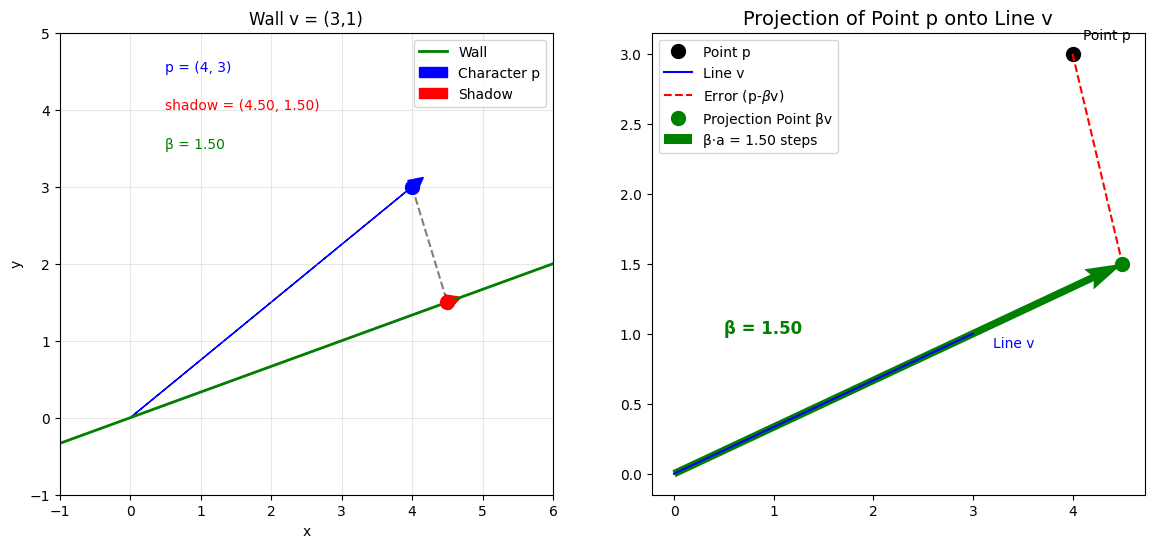

In [63]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
t = np.linspace(-1, 6, 100)
plt.plot(t, (v[1]/v[0]) * t, 'g-', linewidth=2, label='Wall')
# Plot points
plt.arrow(0, 0, p[0], p[1], head_width=0.2, head_length=0.2, fc='blue', ec='blue', label='Character p')
plt.arrow(0, 0, projection[0], projection[1], head_width=0.2, head_length=0.2, fc='red', ec='red', label='Shadow')
# Draw dashed line (perpendicular)
plt.plot([p[0], projection[0]], [p[1], projection[1]], 'k--', alpha=0.5)
plt.scatter(*p, color='blue', s=100, zorder=5)
plt.scatter(*projection, color='red', s=100, zorder=5)
plt.grid(True, alpha=0.3)
plt.xlim(-1, 6)
plt.ylim(-1, 5)
plt.title('Wall v = (3,1)', fontsize=12)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.text(0.5, 4.5, f'p = ({p[0]}, {p[1]})', color='blue')
plt.text(0.5, 4.0, f'shadow = ({projection[0]:.2f}, {projection[1]:.2f})', color='red')
plt.text(0.5, 3.5, f'β = {beta:.2f}', color='green')

plt.subplot(1, 2, 2)
plt.plot(p[0], p[1], 'ko', markersize=10, label='Point p') # point b
plt.plot([0, v[0]], [0, v[1]], 'b', label='Line v') # line a
plt.plot([p[0], projection[0]], [p[1], projection[1]], 'r--', label=r'Error (p-$\beta$v)')
plt.plot(projection[0], projection[1], 'go', markersize=10, label='Projection Point βv')
plt.quiver(0, 0, beta*v[0], beta*v[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, label=f'β·a = {beta:.2f} steps')
plt.annotate(f'β = {beta:.2f}', (beta*v/2), fontsize=12, color='green', fontweight='bold', xytext=(0.5, 1))
plt.text(x=p[0]+.1, y=p[1]+.1, s='Point p')
plt.text(x=v[0]+.2, y=v[1]-0.1, s='Line v', color='b')
plt.legend()
plt.title('Projection of Point p onto Line v', fontsize=14)

In [64]:

v = np.array([1, 1]) # line (wall)
p = np.array([5, 2]) # point (character point)

beta = (p@v) / (v@v)
projection = beta*v
print(f'beta: {beta}')
print(f'projection: {projection}')

beta: 3.5
projection: [3.5 3.5]


Text(0.5, 1.0, 'Projection of Point p onto Line v')

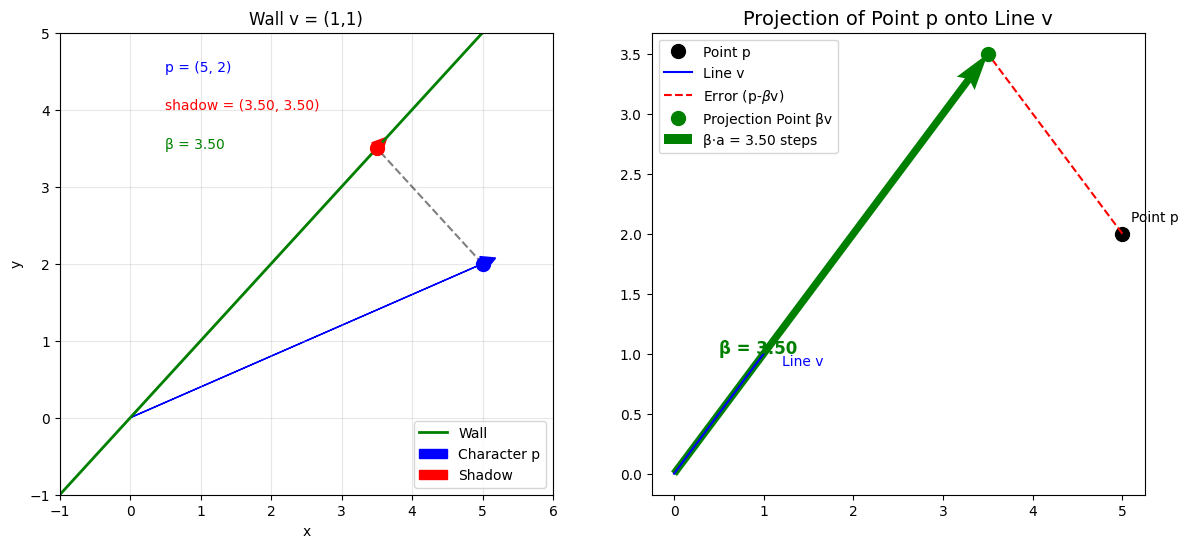

In [66]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
t = np.linspace(-1, 6, 100)
plt.plot(t, (v[1]/v[0]) * t, 'g-', linewidth=2, label='Wall')
# Plot points
plt.arrow(0, 0, p[0], p[1], head_width=0.2, head_length=0.2, fc='blue', ec='blue', label='Character p')
plt.arrow(0, 0, projection[0], projection[1], head_width=0.2, head_length=0.2, fc='red', ec='red', label='Shadow')
# Draw dashed line (perpendicular)
plt.plot([p[0], projection[0]], [p[1], projection[1]], 'k--', alpha=0.5)
plt.scatter(*p, color='blue', s=100, zorder=5)
plt.scatter(*projection, color='red', s=100, zorder=5)
plt.grid(True, alpha=0.3)
plt.xlim(-1, 6)
plt.ylim(-1, 5)
plt.title('Wall v = (1,1)', fontsize=12)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.text(0.5, 4.5, f'p = ({p[0]}, {p[1]})', color='blue')
plt.text(0.5, 4.0, f'shadow = ({projection[0]:.2f}, {projection[1]:.2f})', color='red')
plt.text(0.5, 3.5, f'β = {beta:.2f}', color='green')

plt.subplot(1, 2, 2)
plt.plot(p[0], p[1], 'ko', markersize=10, label='Point p') # point b
plt.plot([0, v[0]], [0, v[1]], 'b', label='Line v') # line a
plt.plot([p[0], projection[0]], [p[1], projection[1]], 'r--', label=r'Error (p-$\beta$v)')
plt.plot(projection[0], projection[1], 'go', markersize=10, label='Projection Point βv')
plt.quiver(0, 0, beta*v[0], beta*v[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.015, label=f'β·a = {beta:.2f} steps')
plt.annotate(f'β = {beta:.2f}', (beta*v/2), fontsize=12, color='green', fontweight='bold', xytext=(0.5, 1))
plt.text(x=p[0]+.1, y=p[1]+.1, s='Point p')
plt.text(x=v[0]+.2, y=v[1]-0.1, s='Line v', color='b')
plt.legend()
plt.title('Projection of Point p onto Line v', fontsize=14)